In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#cargar Data:
customers_aditionals = pd.read_csv("Datos_Limpios.csv")

comenzamos a analizar los datos iniciales y sus distribuciones

<Axes: ylabel='Frequency'>

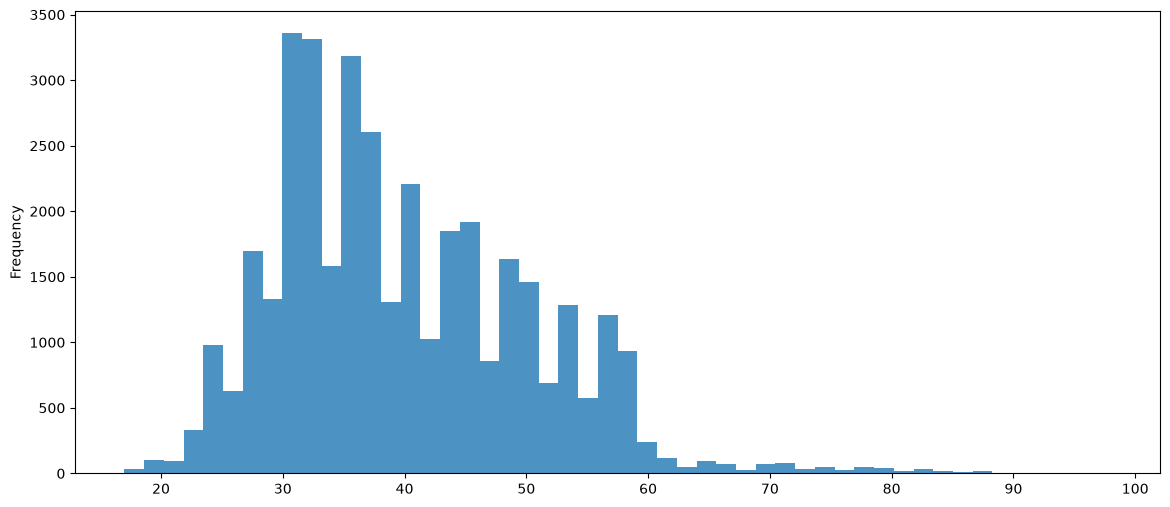

In [ ]:
customers_aditionals['age'].plot(kind='hist', bins=50, alpha=0.8 ,figsize=(14,6))

In [ ]:
customers_aditionals['grupo_edad'].value_counts()


### 1. Variable objetivo `y` (¿contrató el depósito?)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
conteo_y = customers_aditionals['y'].value_counts()
conteo_y.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])

for i, v in enumerate(conteo_y):
    ax.text(i, v, f'{v}\n({v/conteo_y.sum():.1%})', ha='center', va='bottom')

ax.set_title('Distribución de la variable objetivo (y)')
ax.set_xlabel('¿Contrató el depósito?')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. Distribución de variables numéricas clave

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

customers_aditionals['age'].plot(kind='hist', bins=40, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de edad')
axes[0].set_xlabel('Edad')

customers_aditionals['duration'].plot(kind='hist', bins=40, ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('Duración de la llamada (segundos)')
axes[1].set_xlabel('Duración')

customers_aditionals['campaign'].plot(kind='hist', bins=40, ax=axes[2], color='#C44E52', edgecolor='white')
axes[2].set_title('Número de contactos en la campaña')
axes[2].set_xlabel('Campaign')

plt.tight_layout()
plt.show()

### 3. Variables categóricas principales

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

customers_aditionals['job'].value_counts().plot(kind='barh', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Ocupación (job)')
axes[0, 0].invert_yaxis()

customers_aditionals['education'].value_counts().plot(kind='barh', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Nivel educativo')
axes[0, 1].invert_yaxis()

customers_aditionals['marital'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Estado civil')
axes[1, 0].tick_params(axis='x', rotation=0)

customers_aditionals['poutcome'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Resultado de campaña anterior')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4. Grupo de edad vs variable objetivo

In [ ]:
tabla_edad_y = pd.crosstab(customers_aditionals['grupo_edad'], customers_aditionals['y'])

fig, ax = plt.subplots(figsize=(8, 5))
tabla_edad_y.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Contratación del depósito por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Duración y número de contactos según el resultado

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

customers_aditionals.boxplot(column='duration', by='y', ax=axes[0])
axes[0].set_title('Duración de la llamada por resultado')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Duración (segundos)')

customers_aditionals.boxplot(column='campaign', by='y', ax=axes[1])
axes[1].set_title('Número de contactos por resultado')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Campaign')

plt.suptitle('')
plt.tight_layout()
plt.show()

### 6. Correlación entre variables numéricas

In [ ]:
columnas_numericas = ['age', 'duration', 'campaign', 'pdays', 'previous',
                       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                       'euribor3m', 'nr.employed']

correlacion = customers_aditionals[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

### 7. Contactos a lo largo del tiempo

In [ ]:
contactos_por_mes = customers_aditionals.set_index('date').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 4))
contactos_por_mes.plot(kind='line', marker='o', ax=ax, color='#4C72B0')
ax.set_title('Número de contactos por mes')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de contactos')
plt.tight_layout()
plt.show()

In [ ]:
clientes_con_deposito = customers_aditionals[customers_aditionals['y'] == 'yes']
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['age'].plot(kind='hist', bins=30, color='#DD8452', edgecolor='black', ax=ax)
ax.set_title('Distribución de la edad de clientes que contrataron el depósito')
ax.set_xlabel('Edad')
ax.set_ylabel('Numero de Clientes')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['duration'].plot(kind='hist', bins=40, color='#DD8452', edgecolor='black', ax=ax)
ax.set_title('Distribución de la duración de la llamada de clientes que contrataron el depósito')
ax.set_xlabel('Duración (segundos)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['job'].value_counts().plot(kind='barh', color=['#DD8452'], ax=ax)
ax.set_title('Distribución de la ocupación de clientes que contrataron el depósito')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Ocupación')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['education'].value_counts().plot(kind='barh', color=['#DD8452'], ax=ax)
ax.set_title('Distribución del nivel educativo de clientes que contrataron el depósito')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Nivel educativo')
ax.invert_yaxis()
plt.tight_layout()
plt.show()